In [1]:
# ==========================
# Modified K-Means From Scratch
# ==========================

import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Sample Dataset
# --------------------------
X = np.array([
    [1,2],
    [2,1],
    [2,3],
    [3,2],
    [8,8],
    [9,8],
    [8,9],
    [9,9]
])


In [2]:
# --------------------------
# Step 1: Modified Initialization
# (Farthest Point Initialization)
# --------------------------
def initialize_centroids(data, k):
    centroids = []

    # First centroid
    centroids.append(data[np.random.randint(len(data))])

    # Remaining centroids
    for _ in range(k - 1):

        distances = []

        for point in data:
            d = min(np.linalg.norm(point - c) for c in centroids)
            distances.append(d)

        farthest_index = np.argmax(distances)
        centroids.append(data[farthest_index])

    return np.array(centroids)


In [3]:

# --------------------------
# Step 2: Assign Clusters
# --------------------------
def assign_clusters(data, centroids):

    clusters = []

    for point in data:
        distances = [np.linalg.norm(point - c) for c in centroids]
        clusters.append(np.argmin(distances))

    return np.array(clusters)


In [4]:

# --------------------------
# Step 3: Update Centroids
# --------------------------
def update_centroids(data, clusters, k):

    new_centroids = []

    for i in range(k):

        cluster_points = data[clusters == i]

        if len(cluster_points) == 0:
            new_centroids.append(data[np.random.randint(len(data))])
        else:
            new_centroids.append(cluster_points.mean(axis=0))

    return np.array(new_centroids)


In [5]:

# --------------------------
# Step 4: Modified K-Means
# --------------------------
def modified_kmeans(data, k, max_iters=100):

    centroids = initialize_centroids(data, k)

    for i in range(max_iters):

        clusters = assign_clusters(data, centroids)

        new_centroids = update_centroids(data, clusters, k)

        if np.allclose(centroids, new_centroids):
            print("Converged after", i+1, "iterations")
            break

        centroids = new_centroids

    return clusters, centroids


In [6]:
# --------------------------
# Run Model
# --------------------------
k = 2

clusters, centroids = modified_kmeans(X, k)

Converged after 2 iterations


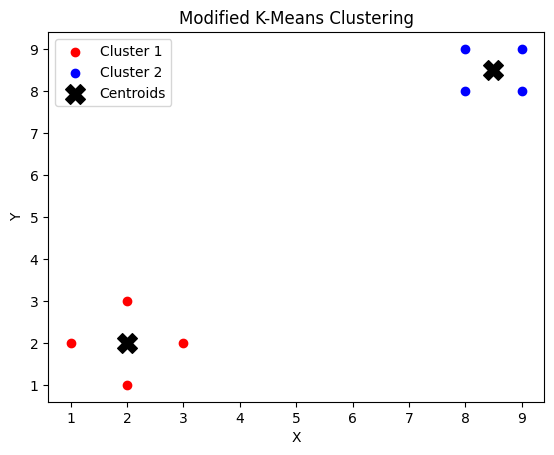

In [7]:

# --------------------------
# Visualization
# --------------------------
colors = ['red', 'blue', 'green', 'purple']

for i in range(k):
    points = X[clusters == i]
    plt.scatter(points[:,0], points[:,1],
                color=colors[i],
                label=f'Cluster {i+1}')

plt.scatter(centroids[:,0],
            centroids[:,1],
            color='black',
            marker='X',
            s=200,
            label='Centroids')

plt.title("Modified K-Means Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()